# RNN实验
韩佳轩，23281106，计算机科学与技术学院

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import time
import numpy as np
import matplotlib.pyplot as plt

# 导入数据集和工具函数
from datasets import TrafficDataset, my_Dataset
from utils import train, test, visualize, plot_metric

In [2]:
torch.manual_seed(23281106)  # 设置随机种子以确保结果可复现

## 手动实现RNN

In [3]:
class MyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        
        # 可学习参数
        self.w_h = nn.Parameter(torch.rand(input_size, hidden_size))
        self.u_h = nn.Parameter(torch.rand(hidden_size, hidden_size))
        self.b_h = nn.Parameter(torch.zeros(hidden_size))
        
        self.w_y = nn.Parameter(torch.rand(hidden_size, output_size))
        self.b_y = nn.Parameter(torch.zeros(output_size))
        
        # 激活函数
        self.tanh = nn.Tanh()
        self.leaky_relu = nn.LeakyReLU()
        
        # 参数初始化（Xavier）
        for param in self.parameters():
            if param.dim() > 1:
                nn.init.xavier_uniform_(param)
    
    def forward(self, x):
        batch_size = x.size(0)
        seq_len = x.size(1)
        
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)
        y_list = []
        
        for i in range(seq_len):
            h = self.tanh(
                torch.matmul(x[:, i, :], self.w_h) +
                torch.matmul(h, self.u_h) + 
                self.b_h
            )
            y = self.leaky_relu(
                torch.matmul(h, self.w_y) + self.b_y
            )
            y_list.append(y)
        
        return torch.stack(y_list, dim=1), h

In [4]:
# 超参数设置
sensor = 171
window_size = 12
target = 'pm25'
batch_size = 64
hidden_size = 64
learning_rate = 0.001
num_epoch = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")    

Using device: cuda


In [5]:
# 数据加载,使用TrafficDataset
print("Loading dataset...")
dataset = TrafficDataset(sensor=96)
train_set, val_set, test_set = dataset.construct_set(
        train_por=0.6, test_por=0.2, window_size=window_size
    )
    
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)
    
input_size = train_set.X.shape[-1] 
print(f"Input size: {input_size}, Samples: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")

Loading dataset...
Input size: 3, Samples: train=10701, val=3559, test=3560


In [6]:
# 模型、损失、优化器
model = MyRNN(input_size=input_size, hidden_size=hidden_size, output_size=1).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
# 反标准化函数（用于评估真实物理量）
def denormalize_fn(x):
    return dataset.denormalize(x.squeeze(-1))

In [7]:
# 训练
print("Start training MyRNN...")
start_time = time.time()
    
train_loss_lst, val_loss_lst, train_score_lst, val_score_lst, best_epoch = train(
        net=model,
        train_iter=train_loader,
        val_iter=val_loader,
        test_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        optimizer=optimizer,
        num_epoch=num_epoch,
        early_stop=10,
        device=device,
        output_model=None,          # 直接使用RNN最后一层输出
        is_print=True,
        is_print_batch=False
    )
    
total_time = time.time() - start_time
print(f"Training finished. Total time: {total_time:.2f}s")

    # 测试集最终评估
test_score, test_loss = test(
        net=model,
        output_model=None,
        data_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        device=device
    )
print("Final Test Result:")
print(f"RMSE: {test_score[0]:.4f}   MAE: {test_score[1]:.4f}   MAPE: {test_score[2]:.2f}%")

Start training MyRNN...
*** epoch1, train loss 0.0015, train rmse 36.5197, val loss 0.0006, val rmse 25.851935, time use 2.507s
*** epoch2, train loss 0.0005, train rmse 25.5969, val loss 0.0004, val rmse 23.022506, time use 1.926s
*** epoch3, train loss 0.0004, train rmse 23.3452, val loss 0.0004, val rmse 21.888296, time use 1.837s
*** epoch4, train loss 0.0004, train rmse 22.3438, val loss 0.0004, val rmse 20.983488, time use 2.074s
*** epoch5, train loss 0.0004, train rmse 21.9413, val loss 0.0004, val rmse 20.746035, time use 2.043s
*** epoch6, train loss 0.0004, train rmse 22.0571, val loss 0.0003, val rmse 20.404156, time use 2.252s
*** epoch7, train loss 0.0004, train rmse 21.8268, val loss 0.0004, val rmse 21.040347, time use 2.085s
*** epoch8, train loss 0.0004, train rmse 21.9852, val loss 0.0004, val rmse 20.977430, time use 2.452s
*** epoch9, train loss 0.0004, train rmse 22.4928, val loss 0.0004, val rmse 22.146689, time use 2.013s
*** epoch10, train loss 0.0004, train rm

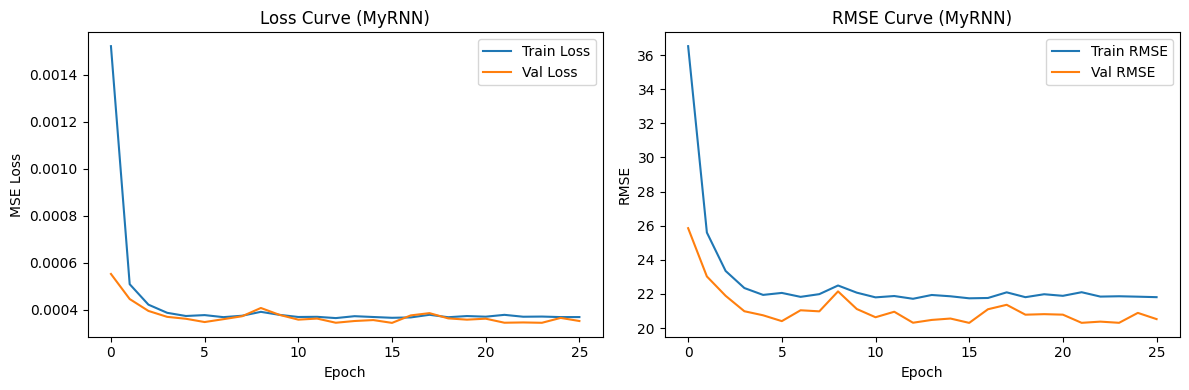

In [8]:
# 可视化
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_lst, label='Train Loss')
plt.plot(val_loss_lst, label='Val Loss')
plt.title('Loss Curve (MyRNN)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
    
plt.subplot(1, 2, 2)
score_array = np.array(train_score_lst)
plt.plot(score_array[:, 0], label='Train RMSE')
val_score_array = np.array(val_score_lst)
plt.plot(val_score_array[:, 0], label='Val RMSE')
plt.title('RMSE Curve (MyRNN)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.savefig('MyRNN_training_curve.png')
plt.show()

## Torch.nn实现RNN

In [9]:
class TorchRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.output(out), None  # 返回out和dummy hidden

In [10]:
# 模型、损失、优化器
model_Torch = TorchRNN(input_size=input_size, hidden_size=hidden_size, output_size=1).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_Torch.parameters(), lr=learning_rate)

In [11]:
# 训练
print("Start training TorchRNN...")
start_time = time.time()
    
train_loss_lst, val_loss_lst, train_score_lst, val_score_lst, best_epoch = train(
        net=model_Torch,
        train_iter=train_loader,
        val_iter=val_loader,
        test_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        optimizer=optimizer,
        num_epoch=num_epoch,
        early_stop=10,
        device=device,
        output_model=None,          # 直接使用RNN最后一层输出
        is_print=True,
        is_print_batch=False
    )
    
total_time = time.time() - start_time
print(f"Training finished. Total time: {total_time:.2f}s")

    # 测试集最终评估
test_score, test_loss = test(
        net=model_Torch,
        output_model=None,
        data_iter=test_loader,
        loss_fn=loss_fn,
        denormalize_fn=denormalize_fn,
        device=device
    )
print("Final Test Result:")
print(f"RMSE: {test_score[0]:.4f}   MAE: {test_score[1]:.4f}   MAPE: {test_score[2]:.2f}%")

Start training TorchRNN...
*** epoch1, train loss 0.0011, train rmse 33.6237, val loss 0.0004, val rmse 21.455840, time use 0.671s
*** epoch2, train loss 0.0004, train rmse 22.3775, val loss 0.0004, val rmse 20.501305, time use 0.691s
*** epoch3, train loss 0.0004, train rmse 22.5471, val loss 0.0004, val rmse 20.928549, time use 0.634s
*** epoch4, train loss 0.0004, train rmse 22.5199, val loss 0.0006, val rmse 28.427267, time use 0.731s
*** epoch5, train loss 0.0004, train rmse 22.4277, val loss 0.0003, val rmse 20.367064, time use 0.654s
*** epoch6, train loss 0.0004, train rmse 21.9675, val loss 0.0004, val rmse 21.626733, time use 0.726s
*** epoch7, train loss 0.0004, train rmse 22.2479, val loss 0.0003, val rmse 20.324558, time use 0.717s
*** epoch8, train loss 0.0004, train rmse 22.1462, val loss 0.0004, val rmse 21.643277, time use 0.664s
*** epoch9, train loss 0.0004, train rmse 22.2956, val loss 0.0004, val rmse 20.729264, time use 0.622s
*** epoch10, train loss 0.0004, train

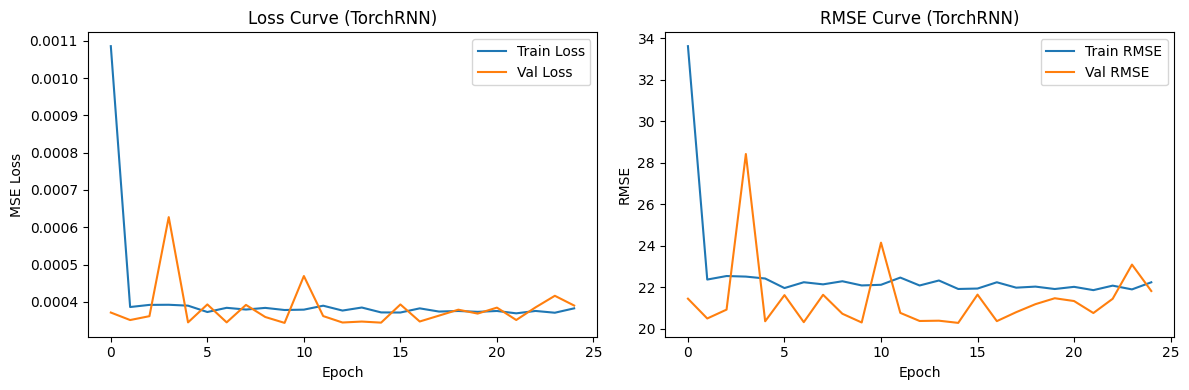

In [12]:
# 可视化
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_lst, label='Train Loss')
plt.plot(val_loss_lst, label='Val Loss')
plt.title('Loss Curve (TorchRNN)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
    
plt.subplot(1, 2, 2)
score_array = np.array(train_score_lst)
plt.plot(score_array[:, 0], label='Train RMSE')
val_score_array = np.array(val_score_lst)
plt.plot(val_score_array[:, 0], label='Val RMSE')
plt.title('RMSE Curve (TorchRNN)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.savefig('TorchRNN_training_curve.png')
plt.show()